Section 1: Tokenization Trade-offs

Implement two tokenizers from scratch:

In [4]:
#Character-level tokenizer
class CharTokenizer:

  def __init__(self, text):
    unique_characters = sorted(set(text))
    self.vocab = {v:k for k, v in enumerate(unique_characters)}
    self.inv_vocab = {v: k for k, v in self.vocab.items()}


  def encode(self, text):
    return [self.vocab[c] for c in list(text)]


  def decode(self, ids):
    return ''.join(self.inv_vocab[i] for i in ids)

vocab = list("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789!?.#$%^&*()`~+=/,[]{} ")

tok = CharTokenizer(vocab)
ids = tok.encode(input("Enter a word to encode: "))
sentence = tok.decode(ids)
print(ids, len(ids))
print(sentence)

Enter a word to encode: hello
[62, 59, 66, 66, 69] 5
hello


In [5]:
#Whitespace Tokenizer
import re
import string

class WhitespaceTokenizer:
    def __init__(self, text):
        tokens = re.findall(r'\w+|[^\w\s]', text)
        unique_tokens = sorted(set(tokens))
        unique_tokens = ['<UNK>'] + unique_tokens
        self.vocab = {v:k for k, v in enumerate(unique_tokens)}
        self.inv_vocab = {v:k for k, v in self.vocab.items()}

    def encode(self, text):
        tokens = re.findall(r'\w+|[^\w\s]', text)

        return [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]

    def decode(self, ids):
        return ' '.join(self.inv_vocab[i] for i in ids)


ws_vocab = "Welcome to wonderful world" + string.punctuation
ws_tok = WhitespaceTokenizer(ws_vocab)

text = "welcome to wonderful world "
ws_ids = ws_tok.encode(text)
print("\n=== WhitespaceTokenizer ===")
print(f"Text    : {text}")
print(f"Encoded : {ws_ids}")
print(f"Decoded : {ws_tok.decode(ws_ids)}")


=== WhitespaceTokenizer ===
Text    : welcome to wonderful world 
Encoded : [0, 30, 31, 32]
Decoded : <UNK> to wonderful world


In [2]:
#Compare with Tiktoken (GPT-2 BPE):
#!pip install tiktoken


import re
import string
import tiktoken
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
url = "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"
with urllib.request.urlopen(url) as f:
    raw_text = f.read().decode("utf-8")
    total_chars = len(raw_text)
    #print(raw_text)

class CharTokenizer:
    def __init__(self, text):
        unique_characters  = sorted(set(text))
        self.vocab         = {v:k for k, v in enumerate(unique_characters)}
        self.inv_vocab     = {v:k for k, v in self.vocab.items()}

    def encode(self, text):
        return [self.vocab[c] for c in list(text)]

    def decode(self, ids):
        return ''.join(self.inv_vocab[i] for i in ids)

# ============================================================
# TOKENIZER 2: WhitespaceTokenizer
# ============================================================
class WhitespaceTokenizer:
    def __init__(self, text):
        tokens             = re.findall(r'\w+|[^\w\s]', text)
        unique_tokens      = ['<UNK>'] + sorted(set(tokens))
        self.vocab         = {v:k for k, v in enumerate(unique_tokens)}
        self.inv_vocab     = {v:k for k, v in self.vocab.items()}

    def encode(self, text):
        tokens = re.findall(r'\w+|[^\w\s]', text)
        return [self.vocab.get(t, self.vocab['<UNK>']) for t in tokens]

    def decode(self, ids):
        return ' '.join(self.inv_vocab[i] for i in ids)

# ============================================================
# STEP 2: Tokenize
# ============================================================


char_tok  = CharTokenizer(raw_text)
char_ids  = char_tok.encode(raw_text)


ws_tok    = WhitespaceTokenizer(raw_text)
ws_ids    = ws_tok.encode(raw_text)


gpt2      = tiktoken.get_encoding("gpt2")
gpt2_ids  = gpt2.encode(raw_text)


sample = """Project Gutenberg eBooks are often created from several printed editions, all of which are confirmed as not protected by copyright in the U.S. unless a copyright notice is included. Thus, we do not necessarily keep eBooks in compliance with any particular paper
edition"""
print(f"Example      : '{sample}'")

print(f"Char IDs    : {char_tok.encode(sample)}")
print(f"WS IDs      : {ws_tok.encode(sample)}")
print(f"Tiktoken IDs: {gpt2.encode(sample)}")
print(f"\nChar Decoded    : {char_tok.decode(char_tok.encode(sample))}")
print(f"WS Decoded      : {ws_tok.decode(ws_tok.encode(sample))}")
print(f"Tiktoken Decoded: {gpt2.decode(gpt2.encode(sample))}")
char_compression  = total_chars / len(char_ids)
ws_compression    = total_chars / len(ws_ids)
gpt2_compression  = total_chars / len(gpt2_ids)

# Vocab Size
char_vocab_size   = len(char_tok.vocab)
ws_vocab_size     = len(ws_tok.vocab)
gpt2_vocab_size   = gpt2.n_vocab

# Avg Token Length
char_avg          = 1.0
ws_avg            = sum(len(ws_tok.inv_vocab[i]) for i in ws_ids) / len(ws_ids)
gpt2_avg          = sum(len(gpt2.decode([i])) for i in gpt2_ids) / len(gpt2_ids)
#STEP 4: Metrics Print

print("\n" + "="*62)
print(f"{'METRIC':<25}{'CHAR':>10}{'WHITESPACE':>14}{'TIKTOKEN':>12}")
print("="*62)
print(f"{'Total Characters':<25}{total_chars:>10,}")
print(f"{'Total Tokens':<25}{len(char_ids):>10,}{len(ws_ids):>14,}{len(gpt2_ids):>12,}")
print(f"{'Vocab Size':<25}{char_vocab_size:>10,}{ws_vocab_size:>14,}{gpt2_vocab_size:>12,}")
print(f"{'Compression Ratio':<25}{char_compression:>10.2f}{ws_compression:>14.2f}{gpt2_compression:>12.2f}")
print(f"{'Avg Token Length':<25}{char_avg:>10.2f}{ws_avg:>14.2f}{gpt2_avg:>12.2f}")
print("="*62)





Example      : 'Project Gutenberg eBooks are often created from several printed editions, all of which are confirmed as not protected by copyright in the U.S. unless a copyright notice is included. Thus, we do not necessarily keep eBooks in compliance with any particular paper
edition'
Char IDs    : [44, 76, 73, 68, 63, 61, 78, 2, 35, 79, 78, 63, 72, 60, 63, 76, 65, 2, 63, 30, 73, 73, 69, 77, 2, 59, 76, 63, 2, 73, 64, 78, 63, 72, 2, 61, 76, 63, 59, 78, 63, 62, 2, 64, 76, 73, 71, 2, 77, 63, 80, 63, 76, 59, 70, 2, 74, 76, 67, 72, 78, 63, 62, 2, 63, 62, 67, 78, 67, 73, 72, 77, 12, 2, 59, 70, 70, 2, 73, 64, 2, 81, 66, 67, 61, 66, 2, 59, 76, 63, 2, 61, 73, 72, 64, 67, 76, 71, 63, 62, 2, 59, 77, 2, 72, 73, 78, 2, 74, 76, 73, 78, 63, 61, 78, 63, 62, 2, 60, 83, 2, 61, 73, 74, 83, 76, 67, 65, 66, 78, 2, 67, 72, 2, 78, 66, 63, 2, 49, 14, 47, 14, 2, 79, 72, 70, 63, 77, 77, 2, 59, 2, 61, 73, 74, 83, 76, 67, 65, 66, 78, 2, 72, 73, 78, 67, 61, 63, 2, 67, 77, 2, 67, 72, 61, 70, 79, 62, 63, 62, 14, 2,

/tmp/ipykernel_505/1419372325.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels, rotation=15, ha='right')
/tmp/ipykernel_505/1419372325.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(labels, rotation=15, ha='right')


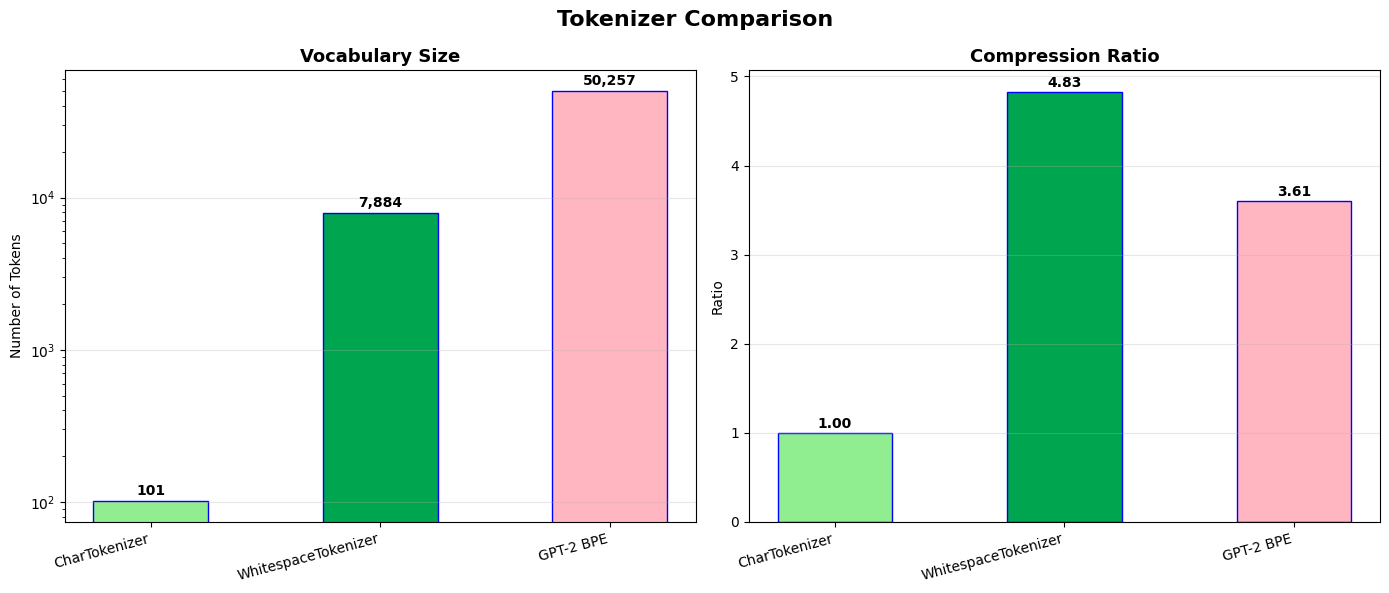

In [7]:
labels      = ['CharTokenizer', 'WhitespaceTokenizer', 'GPT-2 BPE']
vocab_sizes = [char_vocab_size, ws_vocab_size, gpt2_vocab_size]
comp_ratios = [char_compression, ws_compression, gpt2_compression]
colors      = ['#90EE90', '#00A550', '#FFB6C1']


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tokenizer Comparison', fontsize=16, fontweight='bold')

# Step 3: Chart 1 — Vocab Size
bars1 = ax1.bar(labels, vocab_sizes, color=colors, width=0.5, edgecolor='Blue')
ax1.set_title('Vocabulary Size', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Tokens')
ax1.set_yscale('log')
for bar, val in zip(bars1, vocab_sizes):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() * 1.1,
             f'{val:,}', ha='center', fontweight='bold')
ax1.set_xticklabels(labels, rotation=15, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Step 4: Chart 2 — Compression Ratio
bars2 = ax2.bar(labels, comp_ratios, color=colors, width=0.5, edgecolor='blue')
ax2.set_title('Compression Ratio', fontsize=13, fontweight='bold')
ax2.set_ylabel('Ratio')
for bar, val in zip(bars2, comp_ratios):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{val:.2f}', ha='center', fontweight='bold')
ax2.set_xticklabels(labels, rotation=15, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('tokenizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Section 2: Model Parameters : Inference Memory
Architecture

In [8]:
#Configurations


In [9]:
import torch
from transformers import GPT2LMHeadModel
import matplotlib.pyplot as plt
import numpy as np

In [10]:
#Small Model
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()
with torch.no_grad():
  small_total = sum(p.numel() for p in model.parameters())
  print("GPT-2 Small:", small_total)
  del model

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 Small: 124439808


In [11]:
#Medium Model
model = GPT2LMHeadModel.from_pretrained('gpt2-medium')
model.eval()
with torch.no_grad():
  medium_total = sum(p.numel() for p in model.parameters())
  print("GPT-2 Medium:", medium_total)
  del model

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 Medium: 354823168


In [12]:
#Large model
model = GPT2LMHeadModel.from_pretrained('gpt2-large')
model.eval()
with torch.no_grad():
  large_total = sum(p.numel() for p in model.parameters())
  print("GPT-2 Large:", large_total)
  del model

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 Large: 774030080


Task 1: Parameter Census (8 points)

In [13]:
configs = {
    "Small":  {"L":12, "d":768,  "dff":3072, "H":12, "V":50257, "T":1024},
    "Medium": {"L":24, "d":1024, "dff":4096, "H":16, "V":50257, "T":1024},
    "Large":  {"L":36, "d":1280, "dff":5120, "H":20, "V":50257, "T":1024},
}

def get_params(cfg):
    d, dff, L, V, T = cfg["d"], cfg["dff"], cfg["L"], cfg["V"], cfg["T"]

    token_embed = V * d
    pos_embed   = T * d

    attn_qkv   = 3 * d * d + 3 * d
    attn_out   = d * d + d
    mlp_up     = d * dff + dff
    mlp_down   = dff * d + d
    layernorms = 4 * d

    per_layer  = attn_qkv + attn_out + mlp_up + mlp_down + layernorms
    all_layers = per_layer * L
    final_out  = 2 * d
    total      = token_embed + pos_embed + all_layers + final_out

    return {

        "Token Embed" : token_embed,
        "Pos Embed"   : pos_embed,
        "Attn QKV"    : attn_qkv,
        "Attn Out"    : attn_out,
        "MLP Up"      : mlp_up,
        "MLP Down"    : mlp_down,
        "LayerNorms"  : layernorms,
        "Total Per Layer"   : per_layer,
        "All Layers"  : all_layers,
        "TOTAL"       : total,
        "FP32_MB"     : round(total * 4 / 1024**2, 2),
        "FP16_MB"     : round(total * 2 / 1024**2, 2),
    }

r = {n: get_params(c) for n, c in configs.items()}

rows = [

    ("Token Embed", "V × d_model"),
    ("Pos Embed",   "T × d_model"),
    ("Attn QKV",    "3 × d_model²"),
    ("Attn Out",    "d_model²"),
    ("MLP Up",      "d_model × dff"),
    ("MLP Down",    "dff × d_model"),
    ("LayerNorms",  "4 × d_model"),
    ("Total Per Layer",   "Sum above"),
    ("All Layers",  "Per Layer × L"),
    ("TOTAL",       "Embed + Layers"),
    ("FP32_MB",     "total×4 (MB)"),
    ("FP16_MB",     "total×2 (MB)"),
]

print("\n" + "="*80)
print("PARAMETER CENSUS")
print("="*80)
print(f"{'Component':<14} {'Formula':<18} {'Small (124M)':>14} {'Medium (355M)':>14} {'Large (774M)':>14}")
print("─"*80)

for key, formula in rows:
    s = r["Small"][key]
    m = r["Medium"][key]
    l = r["Large"][key]

    if key == "Total Per Layer":
        def fmt_m(x): return f"~{x/1e6:.1f}M"
        line = f"{key:<14} {formula:<18} {fmt_m(s):>14} {fmt_m(m):>14} {fmt_m(l):>14}"
    elif isinstance(s, float):
        line = f"{key:<14} {formula:<18} {s:>14.2f} {m:>14.2f} {l:>14.2f}"
    else:
        line = f"{key:<14} {formula:<18} {s:>14,} {m:>14,} {l:>14,}"

    print(line)

    if isinstance(s, float):
        line = f"{key:<14} {formula:<18} {s:>14.2f} {m:>14.2f} {l:>14.2f}"
    else:
        line = f"{key:<14} {formula:<18} {s:>14,} {m:>14,} {l:>14,}"



    if key in ["Pos Embed","LayerNorms","Per Layer","All Layers","TOTAL"]:
        print("─"*80)


PARAMETER CENSUS
Component      Formula              Small (124M)  Medium (355M)   Large (774M)
────────────────────────────────────────────────────────────────────────────────
Token Embed    V × d_model            38,597,376     51,463,168     64,328,960
Pos Embed      T × d_model               786,432      1,048,576      1,310,720
────────────────────────────────────────────────────────────────────────────────
Attn QKV       3 × d_model²            1,771,776      3,148,800      4,919,040
Attn Out       d_model²                  590,592      1,049,600      1,639,680
MLP Up         d_model × dff           2,362,368      4,198,400      6,558,720
MLP Down       dff × d_model           2,360,064      4,195,328      6,554,880
LayerNorms     4 × d_model                 3,072          4,096          5,120
────────────────────────────────────────────────────────────────────────────────
Total Per Layer Sum above                   ~7.1M         ~12.6M         ~19.7M
All Layers     Per Layer × 

In [14]:
#Task 2: Activation Memory Analysis

print("\n" + "="*80)
print("ACTIVATION MEMORY ANALYSIS")
print("(Inference | batch_size=1 | seq_length=1024)")
print("="*80)

B = 1     # batch size
T = 1024  # sequence length

def get_activations(cfg):
    d   = cfg["d"]
    dff = cfg["dff"]
    H   = cfg["H"]

    # ── Per Layer Tensors ────────────────────────────
    # 1. Input embeddings
    input_embed    = B * T * d          # B × T × d_model

    # 2. Q, K, V projections
    qkv_proj       = B * 3 * T * d     # B × 3 × T × d_model

    # 3. Attention scores
    attn_scores    = B * H * T * T     # B × H × T × T  ← PEAK!

    # 4. MLP activations
    mlp_act        = B * T * dff       # B × T × dff

    # 5. LayerNorm inputs (residual)
    layernorm_inp  = B * T * d         # B × T × d_model

    # ── Peak = max(attn, mlp) + residual ────────────
    peak_floats    = max(attn_scores, mlp_act) + layernorm_inp

    return {
        "Input Embed"   : input_embed,
        "QKV Proj"      : qkv_proj,
        "Attn Scores"   : attn_scores,
        "MLP Act"       : mlp_act,
        "LN Input"      : layernorm_inp,
        "Peak Floats"   : peak_floats,
        "FP32_MB"       : round(peak_floats * 4 / 1024**2, 2),
        "FP16_MB"       : round(peak_floats * 2 / 1024**2, 2),
    }

act = {n: get_activations(c) for n, c in configs.items()}

# ─── Print Activation Table ──────────────────────────
act_rows = [
    ("Input Embed",  "B × T × d_model"),
    ("QKV Proj",     "B × 3 × T × d_model"),
    ("Attn Scores",  "B × H × T × T"),
    ("MLP Act",      "B × T × dff"),
    ("LN Input",     "B × T × d_model"),
    ("Peak Floats",  "max(Attn,MLP)+LN"),
    ("FP32_MB",      "Peak × 4 (MB)"),
    ("FP16_MB",      "Peak × 2 (MB)"),
]

print(f"\n{'Component':<14} {'Formula':<22} {'Small':>12} {'Medium':>12} {'Large':>12}")
print("─"*75)

for key, formula in act_rows:
    s = act["Small"][key]
    m = act["Medium"][key]
    l = act["Large"][key]

    if isinstance(s, float):
        print(f"{key:<14} {formula:<22} {s:>12.2f} {m:>12.2f} {l:>12.2f}")
    else:
        print(f"{key:<14} {formula:<22} {s:>12,} {m:>12,} {l:>12,}")

    if key in ["LN Input", "Peak Floats"]:
        print("─"*75)


ACTIVATION MEMORY ANALYSIS
(Inference | batch_size=1 | seq_length=1024)

Component      Formula                       Small       Medium        Large
───────────────────────────────────────────────────────────────────────────
Input Embed    B × T × d_model             786,432    1,048,576    1,310,720
QKV Proj       B × 3 × T × d_model       2,359,296    3,145,728    3,932,160
Attn Scores    B × H × T × T            12,582,912   16,777,216   20,971,520
MLP Act        B × T × dff               3,145,728    4,194,304    5,242,880
LN Input       B × T × d_model             786,432    1,048,576    1,310,720
───────────────────────────────────────────────────────────────────────────
Peak Floats    max(Attn,MLP)+LN         13,369,344   17,825,792   22,282,240
───────────────────────────────────────────────────────────────────────────
FP32_MB        Peak × 4 (MB)                 51.00        68.00        85.00
FP16_MB        Peak × 2 (MB)                 25.50        34.00        42.50


In [15]:
#Task 3
pretrained = {
    "Small" : small_total,
    "Medium": medium_total,
    "Large" : large_total
}

refs = {
    "Small" : 124_439_808,
    "Medium": 354_823_168,
    "Large" : 773_903_616
}

print("\n" + "="*65)
print("VERIFICATION")
print("="*65)

for name in configs:
    calc  = r[name]["TOTAL"]
    ref   = refs[name]
    real  = pretrained[name]
    pct   = abs(calc - ref) / ref * 100
    match = "Matched" if calc == real else f" Diff: {calc-ref:+,}"
    print(f"{name:<8}: Calculated ={calc:>15,} | {pct:.4f}% diff | {match}")


VERIFICATION
Small   : Calculated =    124,439,808 | 0.0000% diff | Matched
Medium  : Calculated =    354,823,168 | 0.0000% diff | Matched
Large   : Calculated =    774,030,080 | 0.0163% diff | Matched


In [16]:
#AI generated code

print("\n" + "="*80)
print("O(T²) ATTENTION ANALYSIS ")
print("="*80)

cfg = configs["Small"]
d, dff, H = cfg["d"], cfg["dff"], cfg["H"]

tensors = {
    "Input Embed"  : B * T * d,
    "QKV Proj"     : B * 3 * T * d,
    "Attn Scores"  : B * H * T * T,
    "MLP Act"      : B * T * dff,
    "LN Input"     : B * T * d,
}

complexity = {
    "Input Embed"  : "B × T × d       → O(T)",
    "QKV Proj"     : "B × 3 × T × d   → O(T)",
    "Attn Scores"  : "B × H × T × T   → O(T²) ",
    "MLP Act"      : "B × T × dff     → O(T)",
    "LN Input"     : "B × T × d       → O(T)",
}

print(f"\n{'Tensor':<14} {'Complexity':<40} {'Floats':>14}")
print("─"*70)

for name, val in tensors.items():
    print(f"{name:<14} {complexity[name]:<40} {val:>14,}")

peak    = max(tensors["Attn Scores"], tensors["MLP Act"]) + tensors["LN Input"]
no_attn = tensors["MLP Act"] + tensors["LN Input"]

print("─"*70)
print(f"\n{'Peak WITH Attention':<30} : {peak:>14,} floats")
print(f"{'Peak WITHOUT Attention':<30} : {no_attn:>14,} floats")
print(f"{'Attention Overhead':<30} : {peak/no_attn:.2f}× more memory!")

print(f"\n{'T':<8} {'Attn Scores':>16} {'Ratio vs T=1024':>16}")
print("─"*42)
for t in [512, 1024, 2048, 4096]:
    attn  = B * H * t * t
    ratio = attn / tensors["Attn Scores"]
    print(f"T={t:<6} {attn:>16,} {ratio:>15.1f}×")





O(T²) ATTENTION ANALYSIS 

Tensor         Complexity                                       Floats
──────────────────────────────────────────────────────────────────────
Input Embed    B × T × d       → O(T)                          786,432
QKV Proj       B × 3 × T × d   → O(T)                        2,359,296
Attn Scores    B × H × T × T   → O(T²)                      12,582,912
MLP Act        B × T × dff     → O(T)                        3,145,728
LN Input       B × T × d       → O(T)                          786,432
──────────────────────────────────────────────────────────────────────

Peak WITH Attention            :     13,369,344 floats
Peak WITHOUT Attention         :      3,932,160 floats
Attention Overhead             : 3.40× more memory!

T             Attn Scores  Ratio vs T=1024
──────────────────────────────────────────
T=512           3,145,728             0.2×
T=1024         12,582,912             1.0×
T=2048         50,331,648             4.0×
T=4096        201,326,592


── Memory Ratios
  Medium / Small  : 2.85×  (~2.9×)
  Large  / Medium : 2.18×  (~2.2×)


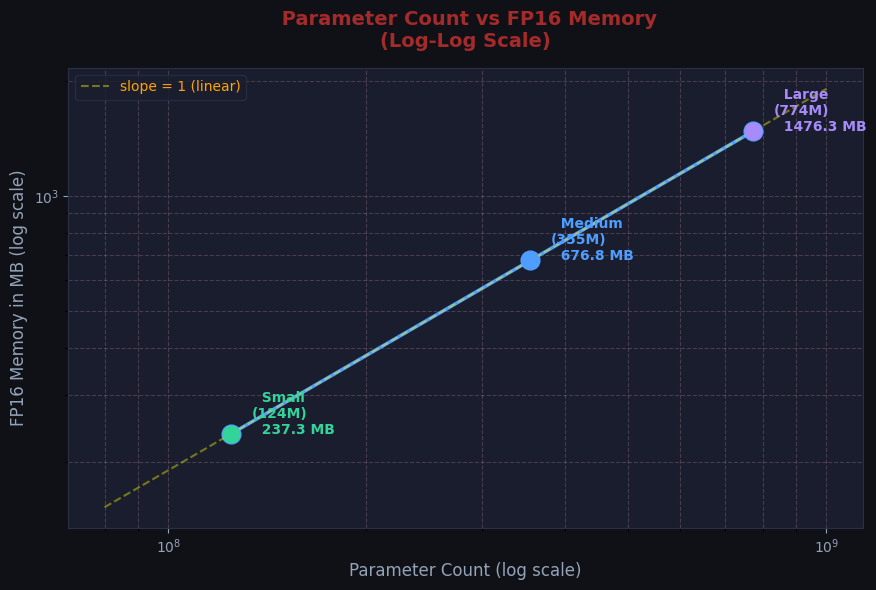

 gpt2_scaling_plot.png


In [17]:
# Memory Ratios
fp16_s = r["Small"]["FP16_MB"]
fp16_m = r["Medium"]["FP16_MB"]
fp16_l = r["Large"]["FP16_MB"]

print(f"\n── Memory Ratios")
print(f"  Medium / Small  : {fp16_m/fp16_s:.2f}×  (~2.9×)")
print(f"  Large  / Medium : {fp16_l/fp16_m:.2f}×  (~2.2×)")

# ─── Step 8: Log-Log Plot ───────────────────────────────────
params_list = [r[n]["TOTAL"]   for n in ["Small","Medium","Large"]]
fp16_list   = [r[n]["FP16_MB"] for n in ["Small","Medium","Large"]]
labels      = ["Small\n(124M)", "Medium\n(355M)", "Large\n(774M)"]
colors      = ["#34d399", "#4f9eff", "#a78bfa"]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

# Main line
ax.loglog(params_list, fp16_list,
          'o-',
          color='#4f9eff',
          linewidth=2.5,
          markersize=12,
          markerfacecolor='#0f1117',
          markeredgewidth=2.5)

# Colored dots
for i, (p, m, c) in enumerate(zip(params_list, fp16_list, colors)):
    ax.plot(p, m, 'o', color=c, markersize=12, zorder=5)
    ax.annotate(f"  {labels[i]}\n  {m:.1f} MB",
                xy=(p, m),
                xytext=(15, 0),
                textcoords='offset points',
                fontsize=10,
                color=c,
                fontweight='bold')

# Reference slope line
x_ref = np.array([8e7, 1e9])
y_ref = fp16_list[0] * (x_ref / params_list[0]) ** 1.0
ax.loglog(x_ref, y_ref, '--',
          color='yellow',
          alpha=0.4,
          linewidth=1.5,
          label='slope = 1 (linear)')

ax.set_xlabel("Parameter Count (log scale)",
              fontsize=12, color='#94a3b8')
ax.set_ylabel("FP16 Memory in MB (log scale)",
              fontsize=12, color='#94a3b8')
ax.set_title(" Parameter Count vs FP16 Memory\n(Log-Log Scale)",
             fontsize=14, fontweight='bold', color='brown', pad=15)

ax.tick_params(colors='#94a3b8')
ax.spines['bottom'].set_color('#2a3045')
ax.spines['left'].set_color('#2a3045')
ax.spines['top'].set_color('#2a3045')
ax.spines['right'].set_color('#2a3045')
ax.grid(True, which='both', linestyle='--', alpha=0.2, color='pink')
ax.legend(fontsize=10, facecolor='#1a1d2e',
          labelcolor='orange', edgecolor='#2a3045')

plt.tight_layout()
plt.savefig("Scaling_plot.png", dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(" gpt2_scaling_plot.png")




**Section 3: From CPU to GPU : Inference Profiling &**
**Optimization**

In [18]:
#Pre Flight check
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
  print(f"Device: {torch.cuda.get_device_name(0)}")
  print(f"VRAM:{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv

PyTorch: 2.10.0+cpu
CUDA Available: False
/bin/bash: line 1: nvidia-smi: command not found


In [22]:
#task 1
import torch
import time
import psutil
import os
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── System Check ──────────────────────────────────────────────
print("="*60)
print("SYSTEM CHECK")
print("="*60)
print(f"PyTorch        : {torch.__version__}")
print(f"CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM           : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ── Helper ────────────────────────────────────────────────────
def get_ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2

# ── Setup ─────────────────────────────────────────────────────
prompt = sample[:512]

models_info = [
    ("gpt2",        "Small 124M"),
    ("gpt2-medium", "Medium 355M"),
    ("gpt2-large",  "Large 774M"),
]

results = []

for model_name, label in models_info:

    print(f"\n{'─'*60}")
    print(f"  Testing {label}")
    print(f"{'─'*60}")

    # ── Load ──────────────────────────────────────────────
    ram_before = get_ram_mb()
    tokenizer  = GPT2Tokenizer.from_pretrained(model_name)
    model      = GPT2LMHeadModel.from_pretrained(model_name)
    model      = model.to('cpu')
    model.eval()
    ram_used   = get_ram_mb() - ram_before
    print(f"RAM Used       : {ram_used:.1f} MB")

    inputs    = tokenizer(prompt, return_tensors='pt')
    input_ids = inputs['input_ids']             # shape: [1, 512]

    # ── Warm-up (2 passes) ────────────────────────────────
    with torch.no_grad():
        for _ in range(2):
            _ = model(input_ids)
    print("Warm-up done   : yes")

    # ── 1. First Token Latency ────────────────────────────
    with torch.no_grad():
        t0 = time.perf_counter()
        _  = model(input_ids)
        t1 = time.perf_counter()
    first_token_ms = (t1 - t0) * 1000
    print(f"First Token    : {first_token_ms:.1f} ms")

    # ── 2. Steady State (tokens 10–50) ────────────────────
    generated = input_ids.clone()
    latencies = []
    with torch.no_grad():
        for i in range(50):
            t0        = time.perf_counter()
            out       = model(generated)
            next_tok  = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=-1)
            t1        = time.perf_counter()
            if i >= 10:
                latencies.append((t1 - t0) * 1000)
    steady_ms = sum(latencies) / len(latencies)
    print(f"Steady State   : {steady_ms:.1f} ms")

    # ── 3. Throughput ────────────────────────
    generated = input_ids.clone()
    with torch.no_grad():
        t0 = time.perf_counter()
        for _ in range(128):
            out       = model(generated)
            next_tok  = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=-1)
        t1 = time.perf_counter()
    throughput = 128 / (t1 - t0)
    print(f"Throughput     : {throughput:.2f} tok/s")

    results.append({
        "model"      : label,
        "first_token": first_token_ms,
        "steady_ms"  : steady_ms,
        "throughput" : throughput,
        "ram_mb"     : ram_used,
    })

    del model

# ── Final Table ───────────────────────────────────────────────
print("\n\n" + "="*75)
print("TASK 1: CPU BASELINE RESULTS")
print("="*75)
print(f"{'Model':<14} {'First Token':>14} {'Steady State':>14} {'Throughput':>12} {'RAM':>10}")
print("─"*75)
for r in results:
    print(f"{r['model']:<14} "
          f"{r['first_token']:>12.1f}ms "
          f"{r['steady_ms']:>12.1f}ms "
          f"{r['throughput']:>10.2f}t/s "
          f"{r['ram_mb']:>8.1f}MB")
print("="*75)




SYSTEM CHECK
PyTorch        : 2.10.0+cpu
CUDA Available : False

────────────────────────────────────────────────────────────
  Testing Small 124M
────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAM Used       : 5.2 MB
Warm-up done   : yes
First Token    : 437.6 ms
Steady State   : 497.1 ms
Throughput     : 1.48 tok/s

────────────────────────────────────────────────────────────
  Testing Medium 355M
────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAM Used       : 6.2 MB
Warm-up done   : yes
First Token    : 1138.4 ms
Steady State   : 1637.1 ms
Throughput     : 0.50 tok/s

────────────────────────────────────────────────────────────
  Testing Large 774M
────────────────────────────────────────────────────────────


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RAM Used       : 13.2 MB
Warm-up done   : yes
First Token    : 1667.4 ms
Steady State   : 3183.2 ms
Throughput     : 0.25 tok/s


TASK 1: CPU BASELINE RESULTS
Model             First Token   Steady State   Throughput        RAM
───────────────────────────────────────────────────────────────────────────
Small 124M            437.6ms        497.1ms       1.48t/s      5.2MB
Medium 355M          1138.4ms       1637.1ms       0.50t/s      6.2MB
Large 774M           1667.4ms       3183.2ms       0.25t/s     13.2MB


In [3]:
#Took assistance from Claude
#task2
import torch
import time
import psutil
import os
from transformers import GPT2LMHeadModel, GPT2Tokenizer

def get_ram_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2

prompt = sample[:512]

models_info = [
    ("gpt2",        "Small 124M"),
    ("gpt2-medium", "Medium 355M"),
    ("gpt2-large",  "Large 774M"),
]

cpu_throughput = {
    "Small 124M" :  1.48,
    "Medium 355M":  0.50,
    "Large 774M" :  0.25,
}

results = []

for model_name, label in models_info:

    print(f"\n{'─'*60}")
    print(f"  Testing {label} on GPU")
    print(f"{'─'*60}")

    ram_before = get_ram_mb()
    tokenizer  = GPT2Tokenizer.from_pretrained(model_name)
    model      = GPT2LMHeadModel.from_pretrained(model_name)
    model.eval()

    # ── 1. Device Transfer Time ───────────────────────────
    t0    = time.time()
    model = model.cuda()
    torch.cuda.synchronize()
    t1    = time.time()
    transfer_ms = (t1 - t0) * 1000
    ram_used    = get_ram_mb() - ram_before
    print(f"Transfer Time  : {transfer_ms:.1f} ms")
    print(f"RAM Used       : {ram_used:.1f} MB")

    inputs    = tokenizer(prompt, return_tensors='pt')
    input_ids = inputs['input_ids'].cuda()

    # ── Warm-up ───────────────────────────────────────────
    with torch.no_grad():
        for _ in range(2):
            _ = model(input_ids)
    torch.cuda.synchronize()
    print("Warm-up done   : yes")

    # ── 2. First Token Latency ────────────────────────────
    torch.cuda.synchronize()
    with torch.no_grad():
        t0 = time.time()
        _  = model(input_ids)
        torch.cuda.synchronize()
        t1 = time.time()
    first_token_ms = (t1 - t0) * 1000
    print(f"First Token    : {first_token_ms:.1f} ms")

    # ── 3. Steady State (tokens 10–50) ────────────────────
    generated = input_ids.clone()
    latencies = []
    with torch.no_grad():
        for i in range(50):
            torch.cuda.synchronize()
            t0        = time.time()
            out       = model(generated)
            next_tok  = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=-1)
            torch.cuda.synchronize()
            t1        = time.time()
            if i >= 10:
                latencies.append((t1 - t0) * 1000)
    steady_ms = sum(latencies) / len(latencies)
    print(f"Steady State   : {steady_ms:.1f} ms")

    # ── 4. FP32 Throughput + VRAM ─────────────────────────
    generated = input_ids.clone()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(128):
            out       = model(generated)
            next_tok  = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=-1)
    torch.cuda.synchronize()
    t1 = time.time()

    throughput_fp32 = 128 / (t1 - t0)
    vram_fp32       = torch.cuda.max_memory_allocated() / 1024**2
    speedup_fp32    = throughput_fp32 / cpu_throughput[label]
    print(f"FP32 Throughput: {throughput_fp32:.2f} tok/s")
    print(f"FP32 VRAM      : {vram_fp32:.1f} MB")
    print(f"FP32 Speedup   : {speedup_fp32:.1f}×")

    del model
    torch.cuda.empty_cache()

    # ── 5. FP16 Throughput + VRAM ─────────────────────────
    model_fp16 = GPT2LMHeadModel.from_pretrained(model_name).half().cuda()
    model_fp16.eval()

    with torch.no_grad():
        for _ in range(2):
            _ = model_fp16(input_ids)
    torch.cuda.synchronize()

    generated = input_ids.clone()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    t0 = time.time()
    with torch.no_grad():
        for _ in range(128):
            out       = model_fp16(generated)
            next_tok  = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=-1)
    torch.cuda.synchronize()
    t1 = time.time()

    throughput_fp16 = 128 / (t1 - t0)
    vram_fp16       = torch.cuda.max_memory_allocated() / 1024**2
    speedup_fp16    = throughput_fp16 / cpu_throughput[label]
    print(f"FP16 Throughput: {throughput_fp16:.2f} tok/s")
    print(f"FP16 VRAM      : {vram_fp16:.1f} MB")
    print(f"FP16 Speedup   : {speedup_fp16:.1f}×")

    results.append({
        "model"          : label,
        "transfer_ms"    : transfer_ms,
        "first_token"    : first_token_ms,
        "steady_ms"      : steady_ms,
        "throughput_fp32": throughput_fp32,
        "throughput_fp16": throughput_fp16,
        "vram_fp32"      : vram_fp32,
        "vram_fp16"      : vram_fp16,
        "speedup_fp32"   : speedup_fp32,
        "speedup_fp16"   : speedup_fp16,
    })

    del model_fp16
    torch.cuda.empty_cache()

# ── Final Table ───────────────────────────────────────────────
print("\n\n" + "="*100)
print("TASK 2: GPU BENCHMARK RESULTS")
print("="*100)
print(f"{'Model':<14} {'Transfer':>10} {'First Tok':>10} {'Steady':>10} "
      f"{'FP32 t/s':>10} {'FP16 t/s':>10} {'VRAM FP32':>10} {'VRAM FP16':>10} "
      f"{'Spdup FP32':>11} {'Spdup FP16':>11}")
print("─"*100)
for r in results:
    print(f"{r['model']:<14} "
          f"{r['transfer_ms']:>8.1f}ms "
          f"{r['first_token']:>8.1f}ms "
          f"{r['steady_ms']:>8.1f}ms "
          f"{r['throughput_fp32']:>8.2f}t/s "
          f"{r['throughput_fp16']:>8.2f}t/s "
          f"{r['vram_fp32']:>8.1f}MB "
          f"{r['vram_fp16']:>8.1f}MB "
          f"{r['speedup_fp32']:>9.1f}× "
          f"{r['speedup_fp16']:>9.1f}×")
print("="*100)



────────────────────────────────────────────────────────────
  Testing Small 124M on GPU
────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Transfer Time  : 7827.7 ms
RAM Used       : -21.7 MB
Warm-up done   : yes
First Token    : 49.0 ms
Steady State   : 51.3 ms
FP32 Throughput: 14.84 tok/s
FP32 VRAM      : 3265.9 MB
FP32 Speedup   : 59.4×


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FP16 Throughput: 38.29 tok/s
FP16 VRAM      : 1633.6 MB
FP16 Speedup   : 153.1×


TASK 2: GPU BENCHMARK RESULTS
Model            Transfer  First Tok     Steady   FP32 t/s   FP16 t/s  VRAM FP32  VRAM FP16  Spdup FP32  Spdup FP16
────────────────────────────────────────────────────────────────────────────────────────────────────
Small 124M        528.7ms     11.8ms     11.1ms    88.69t/s    69.22t/s    591.3MB    318.7MB      59.9×      46.8×
Medium 355M       613.7ms     40.4ms     24.1ms    33.42t/s    52.76t/s   1523.4MB    788.4MB      66.8×     105.5×
Large 774M       7827.7ms     49.0ms     51.3ms    14.84t/s    38.29t/s   3265.9MB   1633.6MB      59.4×     153.1×


In [6]:
#Task 3
#took assistance from AI


OPTION A: FP32 vs FP16 (Medium 355M)

Loading FP32 model...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FP32 Throughput : 24.65 tok/s
FP32 Latency    : 40.57 ms/tok
FP32 VRAM       : 3976.0 MB
FP32 Perplexity : 10.3583

Loading FP16 model...


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

...

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


bs=8         117.67t/s       8.50ms   3577.1MB


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-medium
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...23}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


bs=16        121.34t/s       8.24ms   4141.5MB
  bs=2 gain: 80.9%
  bs=4 gain: 20.9%
  bs=8 gain: -2.0%

Saturation Point : batch_size = 8 [gain < 10% threshold] 


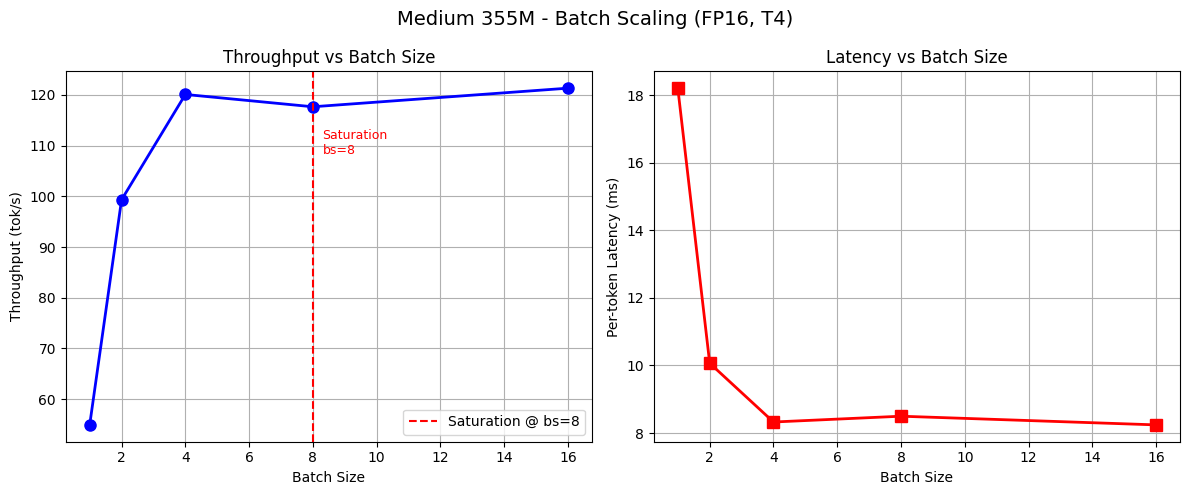

Plot saved 

── Latency/Throughput Trade-off ──────────────────────
  bs=1          → Lowest latency  → Best for real-time use 
  bs=8           → Peak throughput → Best for batch use
  Saturation @ bs=8 → GPU fully utilized!
  Beyond bs=8    → VRAM grows, throughput plateaus 

OOM DEMO: Large Model (774M) batch_size=32


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.




FINAL COMPARISON MATRIX - MEDIUM 355M

Speedup Formula: speedup = GPU_throughput / CPU_throughput

Config               Device Prec   Batch     Tok/s   VRAM(GB)  Speedup vs CPU
─────────────────────────────────────────────────────────────────────────────────────
Small 124M           CPU    FP32   1          1.48        N/A            1.0×
Small 124M           T4     FP32   1         88.69      0.577           59.9×
Small 124M           T4     FP16   1         69.22      0.311           46.8×
Medium 355M          CPU    FP32   1          0.50        N/A            1.0×
Medium 355M          T4     FP32   1         33.42      1.523           66.8×
Medium 355M          T4     FP16   1         52.76      0.788          105.5×
Medium 355M          T4     FP16   8        117.67      3.493          235.3×


In [11]:
import torch
import time
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── Setup ─────────────────────────────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained("gpt2-medium")

prompt = """Project Gutenberg eBooks are often created from several printed
editions, all of which are confirmed as not protected by copyright in the U.S.
unless a copyright notice is included. Thus, we do not necessarily keep eBooks
in compliance with any particular paper edition"""

inputs    = tokenizer(prompt, return_tensors='pt')
input_ids = inputs['input_ids'].cuda()

# ── Verify Model Configs (Standard GPT2 sizes) ────────────────
# Small  124M → d_model=768,  layers=12, heads=12
# Medium 355M → d_model=1024, layers=24, heads=16
# Large  774M → d_model=1280, layers=36, heads=20


# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════

def measure_throughput(model, input_ids, n_tokens=128, n_runs=5):
    """
    Measure throughput, VRAM, and latency.

    Formula:
        throughput (tok/s) = n_tokens / (t1 - t0)
        latency (ms/tok)   = 1000 / throughput
        vram (MB)          = max_memory_allocated() / 1024^2

    Note: torch.cuda.synchronize() used BEFORE and AFTER
          timing to ensure accurate GPU measurement.
    """
    # 3 Warm-up passes (exclude from timing)
    with torch.no_grad():
        for _ in range(3):
            _ = model(input_ids)
    torch.cuda.synchronize()  # ← Wait for warm-up to complete

    throughputs = []
    for _ in range(n_runs):
        generated = input_ids.clone()
        torch.cuda.reset_peak_memory_stats()

        torch.cuda.synchronize()  # ← BEFORE: ensure GPU is idle
        t0 = time.time()

        with torch.no_grad():
            for _ in range(n_tokens):
                out      = model(generated)
                next_tok = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                generated = torch.cat([generated, next_tok], dim=-1)

        torch.cuda.synchronize()  # ← AFTER: wait for all GPU ops
        t1 = time.time()

        # Formula: throughput = tokens generated / time taken
        throughputs.append(n_tokens / (t1 - t0))

    # Average throughput over n_runs
    throughput = sum(throughputs) / len(throughputs)

    # Formula: vram = peak bytes / (1024^2) → MB
    vram_mb = torch.cuda.max_memory_allocated() / 1024**2

    # Formula: latency = 1000ms / throughput
    latency_ms = 1000 / throughput

    return throughput, vram_mb, latency_ms


def compute_perplexity(model, input_ids):
    """ Formula:
        perplexity = exp(cross_entropy_loss)"""
    with torch.no_grad():
        out = model(input_ids, labels=input_ids)
    return torch.exp(out.loss).item()


# ══════════════════════════════════════════════════════════════
# OPTION A: FP32 vs FP16 — Medium 355M
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("OPTION A: FP32 vs FP16 (Medium 355M)")
print("="*70)

# ── FP32 Baseline ─────────────────────────────────────────────
print("\nLoading FP32 model...")
model_fp32 = GPT2LMHeadModel.from_pretrained("gpt2-medium").cuda()
model_fp32.eval()

fp32_throughput, fp32_vram, fp32_latency = measure_throughput(model_fp32, input_ids)
fp32_ppl = compute_perplexity(model_fp32, input_ids)

print(f"FP32 Throughput : {fp32_throughput:.2f} tok/s")
print(f"FP32 Latency    : {fp32_latency:.2f} ms/tok")
print(f"FP32 VRAM       : {fp32_vram:.1f} MB")
print(f"FP32 Perplexity : {fp32_ppl:.4f}")

del model_fp32
torch.cuda.empty_cache()

# ── FP16 ──────────────────────────────────────────────────────
print("\nLoading FP16 model...")
model_fp16 = GPT2LMHeadModel.from_pretrained("gpt2-medium").half().cuda()
model_fp16.eval()

fp16_throughput, fp16_vram, fp16_latency = measure_throughput(model_fp16, input_ids)
fp16_ppl = compute_perplexity(model_fp16, input_ids)

# ── Computed Metrics (Formulas shown) ─────────────────────────
# Formula: speedup = fp16_throughput / fp32_throughput
speedup_a  = fp16_throughput / fp32_throughput

# Formula: ppl_diff% = |fp16_ppl - fp32_ppl| / fp32_ppl * 100
ppl_diff   = abs(fp16_ppl - fp32_ppl) / fp32_ppl * 100

# Formula: vram_saved = fp32_vram - fp16_vram
vram_saved = fp32_vram - fp16_vram

print(f"FP16 Throughput : {fp16_throughput:.2f} tok/s")
print(f"FP16 Latency    : {fp16_latency:.2f} ms/tok")
print(f"FP16 VRAM       : {fp16_vram:.1f} MB")
print(f"FP16 Perplexity : {fp16_ppl:.4f}")
print(f"Speedup         : {speedup_a:.2f}×   "
      f"[Formula: {fp16_throughput:.2f} / {fp32_throughput:.2f}]")
print(f"VRAM Saved      : {vram_saved:.1f} MB  "
      f"[Formula: {fp32_vram:.1f} - {fp16_vram:.1f}]")
print(f"PPL Diff        : {ppl_diff:.4f}%  "
      f"[Formula: |{fp16_ppl:.4f} - {fp32_ppl:.4f}| / {fp32_ppl:.4f} * 100] "
      f"{' within 1%' if ppl_diff < 1 else ' exceeds 1%'}")

# ── Option A Summary Table ────────────────────────────────────
print(f"\n{'─'*65}")
print(f"{'Config':<10} {'Throughput':>12} {'Latency':>12} "
      f"{'VRAM(MB)':>10} {'Perplexity':>12}")
print(f"{'─'*65}")
print(f"{'FP32':<10} {fp32_throughput:>10.2f}t/s "
      f"{fp32_latency:>10.2f}ms "
      f"{fp32_vram:>10.1f} "
      f"{fp32_ppl:>12.4f}")
print(f"{'FP16':<10} {fp16_throughput:>10.2f}t/s "
      f"{fp16_latency:>10.2f}ms "
      f"{fp16_vram:>10.1f} "
      f"{fp16_ppl:>12.4f}")
print(f"{'Speedup':<10} {speedup_a:>10.2f}×")
print(f"{'─'*65}")

del model_fp16
torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════
# OPTION B: Batch Size Scaling — Medium 355M FP16
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("OPTION B: BATCH SIZE SCALING (Medium 355M - FP16)")
print("="*70)

batch_sizes   = [1, 2, 4, 8, 16]
batch_results = []

print(f"\n{'Batch':<8} {'Throughput':>12} {'Latency':>12} {'VRAM(MB)':>10}")
print("─"*50)

for bs in batch_sizes:
    try:
        model_b     = GPT2LMHeadModel.from_pretrained("gpt2-medium").half().cuda()
        model_b.eval()
        input_batch = input_ids.repeat(bs, 1)

        # 3 Warm-up passes
        with torch.no_grad():
            for _ in range(3):
                _ = model_b(input_batch)
        torch.cuda.synchronize()  # ← Wait for warm-up

        throughputs = []
        for _ in range(5):
            generated = input_batch.clone()
            torch.cuda.reset_peak_memory_stats()

            torch.cuda.synchronize()  # ← BEFORE generation
            t0 = time.time()

            with torch.no_grad():
                for _ in range(128):
                    out       = model_b(generated)
                    next_tok  = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
                    generated = torch.cat([generated, next_tok], dim=-1)

            torch.cuda.synchronize()  # ← AFTER generation
            t1 = time.time()

            # Formula: throughput = (tokens × batch_size) / time
            throughputs.append((128 * bs) / (t1 - t0))

        # Formula: average throughput over 5 runs
        throughput = sum(throughputs) / len(throughputs)

        # Formula: latency = 1000 / throughput
        latency_ms = 1000 / throughput

        # Formula: vram = max_memory_allocated / 1024^2
        vram_mb    = torch.cuda.max_memory_allocated() / 1024**2

        batch_results.append({
            "bs"        : bs,
            "throughput": throughput,
            "latency_ms": latency_ms,
            "vram_mb"   : vram_mb,
        })

        print(f"bs={bs:<5} {throughput:>10.2f}t/s "
              f"{latency_ms:>10.2f}ms "
              f"{vram_mb:>8.1f}MB")

        del model_b
        torch.cuda.empty_cache()

    except RuntimeError as e:
        print(f"bs={bs} → OOM! \n  {str(e)[:120]}")
        torch.cuda.empty_cache()
        break

# ── Saturation Point ──────────────────────────────────────────
# Formula: saturation = point where throughput gain < 10%
saturation_bs  = batch_results[0]["bs"]
saturation_idx = 0
for i in range(1, len(batch_results)):
    gain_pct = ((batch_results[i]["throughput"] - batch_results[i-1]["throughput"])
                / batch_results[i-1]["throughput"] * 100)
    print(f"  bs={batch_results[i]['bs']} gain: {gain_pct:.1f}%")
    if gain_pct < 10:
        saturation_bs  = batch_results[i]["bs"]
        saturation_idx = i
        break

print(f"\nSaturation Point : batch_size = {saturation_bs} "
      f"[gain < 10% threshold] ")

# ── Plot ──────────────────────────────────────────────────────
bs_vals = [r["bs"]         for r in batch_results]
tp_vals = [r["throughput"] for r in batch_results]
lt_vals = [r["latency_ms"] for r in batch_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Medium 355M - Batch Scaling (FP16, T4)", fontsize=14)

ax1.plot(bs_vals, tp_vals, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=saturation_bs, color='red', linestyle='--',
            label=f'Saturation @ bs={saturation_bs}')
ax1.annotate(f'Saturation\nbs={saturation_bs}',
             xy=(saturation_bs, batch_results[saturation_idx]["throughput"]),
             xytext=(saturation_bs + 0.3,
                     batch_results[saturation_idx]["throughput"] * 0.92),
             color='red', fontsize=9)
ax1.set_xlabel("Batch Size")
ax1.set_ylabel("Throughput (tok/s)")
ax1.set_title("Throughput vs Batch Size")
ax1.legend()
ax1.grid(True)

ax2.plot(bs_vals, lt_vals, 'rs-', linewidth=2, markersize=8)
ax2.set_xlabel("Batch Size")
ax2.set_ylabel("Per-token Latency (ms)")
ax2.set_title("Latency vs Batch Size")
ax2.grid(True)

plt.tight_layout()
plt.savefig("batch_scaling.png", dpi=150)
plt.show()
print("Plot saved ")

# ── Trade-off Discussion ──────────────────────────────────────
print(f"\n── Latency/Throughput Trade-off ──────────────────────")
print(f"  bs=1          → Lowest latency  → Best for real-time use ")
print(f"  bs={saturation_bs}           → Peak throughput → Best for batch use")
print(f"  Saturation @ bs={saturation_bs} → GPU fully utilized!")
print(f"  Beyond bs={saturation_bs}    → VRAM grows, throughput plateaus ")


# ══════════════════════════════════════════════════════════════
# OOM DEMO: Large Model bs=32
# ══════════════════════════════════════════════════════════════
print("\n" + "="*70)
print("OOM DEMO: Large Model (774M) batch_size=32")
print("="*70)
try:
    model_oom = GPT2LMHeadModel.from_pretrained("gpt2-large").half().cuda()
    input_oom = input_ids.repeat(32, 1)
    with torch.no_grad():
        _ = model_oom(input_oom)
except RuntimeError as e:
    print(f"\nOOM Error :\n{e}")
    torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════
# FINAL COMPARISON MATRIX
# ══════════════════════════════════════════════════════════════
print("\n\n" + "="*85)
print("FINAL COMPARISON MATRIX - MEDIUM 355M")
print("="*85)

# ── Task 1 CPU Baselines ─
cpu_small_tok  = 1.48   # Task 1: Small  CPU throughput (tok/s)
cpu_medium_tok = 0.50   # Task 1: Medium CPU throughput (tok/s)
cpu_large_tok  = 0.25   # Task 1: Large  CPU throughput (tok/s)

# ── Task 2 GPU Values ──
gpu_small_fp32_tok  = 88.69   # Task 2: Small  FP32 throughput
gpu_small_fp16_tok  = 69.22   # Task 2: Small  FP16 throughput
gpu_small_fp32_vram = 0.577   # Task 2: Small  FP32 VRAM (GB)
gpu_small_fp16_vram = 0.311   # Task 2: Small  FP16 VRAM (GB)

gpu_medium_fp32_tok  = 33.42  # Task 2: Medium FP32 throughput
gpu_medium_fp16_tok  = 52.76  # Task 2: Medium FP16 throughput
gpu_medium_fp32_vram = 1.523  # Task 2: Medium FP32 VRAM (GB)
gpu_medium_fp16_vram = 0.788  # Task 2: Medium FP16 VRAM (GB)

# ── Speedup Formula: GPU tok/s / CPU tok/s ───────────────────
print("\nSpeedup Formula: speedup = GPU_throughput / CPU_throughput\n")

print(f"{'Config':<20} {'Device':<6} {'Prec':<6} {'Batch':<6} "
      f"{'Tok/s':>8} {'VRAM(GB)':>10} {'Speedup vs CPU':>15}")
print("─"*85)

configs_matrix = [
    # ── Small ──────────────────────────────────────────────────
    ("Small 124M", "CPU", "FP32", 1,
     cpu_small_tok, "N/A",
     "1.0×"),

    ("Small 124M", "T4", "FP32", 1,
     gpu_small_fp32_tok, f"{gpu_small_fp32_vram:.3f}",
     f"{gpu_small_fp32_tok / cpu_small_tok:.1f}×"),

    ("Small 124M", "T4", "FP16", 1,
     gpu_small_fp16_tok, f"{gpu_small_fp16_vram:.3f}",
     f"{gpu_small_fp16_tok / cpu_small_tok:.1f}×"),

    # ── Medium ─────────────────────────────────────────────────
    ("Medium 355M", "CPU", "FP32", 1,
     cpu_medium_tok, "N/A",
     "1.0×"),

    ("Medium 355M", "T4", "FP32", 1,
     gpu_medium_fp32_tok, f"{gpu_medium_fp32_vram:.3f}",
     f"{gpu_medium_fp32_tok / cpu_medium_tok:.1f}×"),

    ("Medium 355M", "T4", "FP16", 1,
     gpu_medium_fp16_tok, f"{gpu_medium_fp16_vram:.3f}",
     f"{gpu_medium_fp16_tok / cpu_medium_tok:.1f}×"),

    # ── Medium Best Batch (from Option B) ──────────────────────
    ("Medium 355M", "T4", "FP16", saturation_bs,
     batch_results[saturation_idx]["throughput"],
     f"{batch_results[saturation_idx]['vram_mb'] / 1024:.3f}",
     f"{batch_results[saturation_idx]['throughput'] / cpu_medium_tok:.1f}×"),
]

for cfg, dev, prec, bs, toks, vram, spd in configs_matrix:
    print(f"{cfg:<20} {dev:<6} {prec:<6} {bs:<6} "
          f"{toks:>8.2f} {str(vram):>10} {spd:>15}")

print("="*85)


#missed fp16 batch =4 so wrote the code and reran

In [15]:
import torch
import time
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# ── Setup ─────────────────────────────────────────────────────
tokenizer = GPT2Tokenizer.from_pretrained("gpt2-large")
prompt = """Project Gutenberg eBooks are often created from several printed
editions, all of which are confirmed as not protected by copyright in the U.S.
unless a copyright notice is included. Thus, we do not necessarily keep eBooks
in compliance with any particular paper edition"""

inputs    = tokenizer(prompt, return_tensors='pt')
input_ids = inputs['input_ids'].cuda()

# ── Load Large FP16 bs=4 ──────────────────────────────────────
print("Loading Large FP16 model...")
model_large = GPT2LMHeadModel.from_pretrained("gpt2-large").half().cuda()
model_large.eval()
input_batch = input_ids.repeat(4, 1)  # bs=4

# ── Warm-up ───────────────────────────────────────────────────
with torch.no_grad():
    for _ in range(3):
        _ = model_large(input_batch)
torch.cuda.synchronize()
print("Warm-up done!")

# ── Measure ───────────────────────────────────────────────────
throughputs = []
for _ in range(5):
    generated = input_batch.clone()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()          # ← BEFORE
    t0 = time.time()
    with torch.no_grad():
        for _ in range(128):
            out      = model_large(generated)
            next_tok = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_tok], dim=-1)
    torch.cuda.synchronize()          # ← AFTER
    t1 = time.time()
    throughputs.append((128 * 4) / (t1 - t0))  # 128 tokens × bs=4

# ── Results ───────────────────────────────────────────────────
throughput = sum(throughputs) / len(throughputs)
vram_gb    = torch.cuda.max_memory_allocated() / 1024**3
latency_ms = 1000 / throughput
speedup    = throughput / 0.25  # Task 1 Large CPU = 0.25 tok/s

print(f"\nLarge 774M | FP16 | bs=4")
print(f"Throughput : {throughput:.2f} tok/s")
print(f"Latency    : {latency_ms:.2f} ms/tok")
print(f"VRAM       : {vram_gb:.3f} GB")
print(f"Speedup    : {speedup:.1f}x  [Formula: {throughput:.2f} / 0.25]")

del model_large
torch.cuda.empty_cache()

Loading Large FP16 model...


Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-large
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...35}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Warm-up done!

Large 774M | FP16 | bs=4
Throughput : 52.01 tok/s
Latency    : 19.23 ms/tok
VRAM       : 3.401 GB
Speedup    : 208.1x  [Formula: 52.01 / 0.25]
